Decisiones de limpieza - Fases de pirólisis

Se calculó la suma de Solid phase + Liquid phase + Gas phase por fila.
- 712 filas tienen datos completos en las tres fases
- 241 filas (34%) no suman 100% ± 1%

Decisión:
- Filas con suma entre 90-110%: se conservan. 
  Diferencias atribuibles a redondeo experimental o diferencias 
  de base húmeda/seca en el reporte.
- Filas con suma fuera de 90-110% (107 filas): se eliminan.
  Patrón sistemático por especie sugiere fase no medida o 
  error de carga. No es recuperable por imputación.
  16 especies afectadas pero ninguna eliminada completamente.

In [1]:
import pandas as pd
import numpy as np

RAW_PATH = r"C:\Users\santi\Documents\Pyrolisis\Data\pyrolysis.csv"
df = pd.read_csv(RAW_PATH)

In [2]:
df_raw = pd.read_csv(RAW_PATH)
df = df_raw.copy()

In [3]:
df = df_raw.copy()


In [4]:
df['Solid phase'] = pd.to_numeric(df['Solid phase'], errors='coerce')
df['Liquid phase'] = pd.to_numeric(df['Liquid phase'], errors='coerce')
df['Gas phase'] = pd.to_numeric(df['Gas phase'], errors='coerce')

In [5]:
def convertir_ps(valor):
    if pd.isna(valor):
        return np.nan
    if '-' in str(valor):
        partes = str(valor).split('-')
        return (float(partes[0]) + float(partes[1])) / 2
    return float(valor)

df['PS'] = df['PS'].apply(convertir_ps)

In [6]:
df_antes_limpieza = df.copy()  # snapshot antes de eliminar filas


In [7]:
# Verificar que las columnas de fases sumen aproximadamente 100
df['suma_fases'] = df['Solid phase'] + df['Liquid phase'] + df['Gas phase']
print(df['suma_fases'].describe())

# ¿Cuántas filas NO suman aproximadamente 100?
fuera_de_rango = df[(df['suma_fases'] < 99) | (df['suma_fases'] > 101)]
print("Filas que no suman 100 ±1%:", len(fuera_de_rango))
print(fuera_de_rango[['Solid phase', 'Liquid phase', 'Gas phase', 'suma_fases']].head(10))

count    712.000000
mean      96.416882
std        8.006419
min       55.070000
25%       97.980000
50%      100.000000
75%      100.000000
max      118.300000
Name: suma_fases, dtype: float64
Filas que no suman 100 ±1%: 241
    Solid phase  Liquid phase  Gas phase  suma_fases
14        23.33         29.30      45.80       98.43
15        56.69         25.04      14.80       96.53
17        46.56         30.19      21.89       98.64
22        32.60         20.10      46.20       98.90
34        23.12         34.35      40.84       98.31
35        21.48         33.76      42.10       97.34
41        64.87         13.89      23.30      102.06
42        20.99         26.45      55.00      102.44
43        20.78         22.34      60.71      103.83
44        21.10         30.51      52.69      104.30


In [8]:
filas_antes = len(df)
df['suma_fases'] = df['Solid phase'] + df['Liquid phase'] + df['Gas phase']
df = df[(df['suma_fases'] >= 90) & (df['suma_fases'] <= 110)]
df = df.drop(columns=['suma_fases'])
filas_despues = len(df)
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues}")


Filas eliminadas: 146
Filas restantes: 605


In [9]:
print(df[['Solid phase', 'Liquid phase', 'Gas phase']].isnull().sum())


Solid phase     0
Liquid phase    0
Gas phase       0
dtype: int64


## Cierre de masa - decisión de limpieza

Se calculó la suma Solid + Liquid + Gas phase por fila.
Se conservaron solo las filas con suma entre 90% y 110%.

Filas originales: 751
Filas eliminadas: 146
Filas restantes: 605

La eliminación incluyó:
- 107 filas con balance extremo (< 90% o > 110%)
- 39 filas con NaN en alguna fase (suma indefinida, 
  quedaron fuera del filtro automáticamente)

Medianas de FR por grupo de FT (con FR disponible):
FT_grupo
Q1    100.0
Q2    100.0
Q3    100.0
Q4     50.0
Name: FR, dtype: float64

Medianas de FR por grupo de FT (sin FR disponible):
FT_grupo
Q1   NaN
Q2   NaN
Q3   NaN
Q4   NaN
Name: FR, dtype: float64


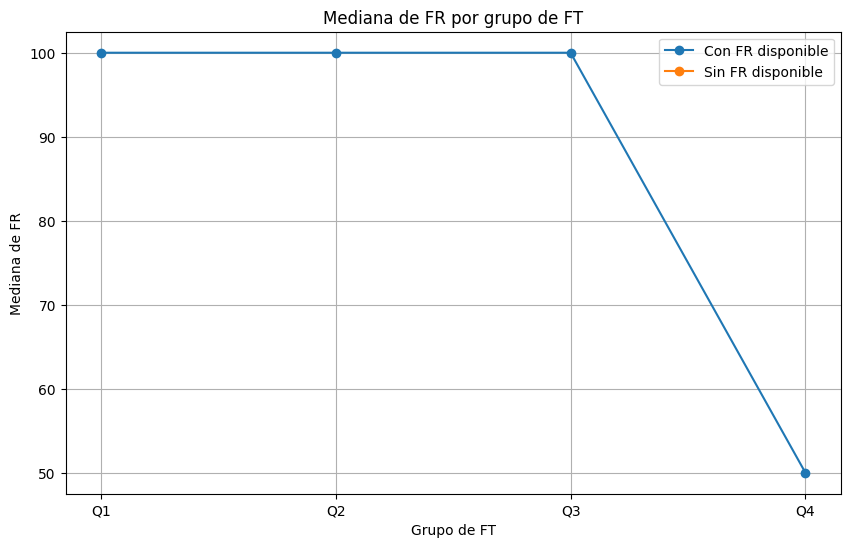

{'Index': nan, 'Biomass species': nan, 'M': '%', 'Ash ': '%', 'VM': '%', 'FC': '%', 'C': '%', 'H': '%', 'O': '%', 'N': '%', 'PS': 'mm', 'FT': '℃', 'HR': '℃', 'FR': 'mL/min', 'Solid phase': '%', 'Liquid phase': '%', 'Gas phase': '%'}
Index: nan
Biomass species: nan
M: %
Ash : %
VM: %
FC: %
C: %
H: %
O: %
N: %
PS: mm
FT: ℃
HR: ℃
FR: mL/min
Solid phase: %
Liquid phase: %
Gas phase: %
FR_disponible: sin unidad
FT_grupo: sin unidad
FR_imputado: sin unidad


In [10]:
#Tres pasos en orden:

#Crear FR_disponible (0/1)
df['FR_disponible'] = df['FR'].notna().astype(int)

#Definir grupos de temperatura FT
df['FT_grupo'] = pd.qcut(df['FT'], q=4, labels=['Q1','Q2','Q3','Q4'])


#Imputar FR con la mediana de cada grupo
df['FR_imputado'] = df.groupby('FT_grupo')['FR'].transform(lambda x: x.fillna(x.median()))
#comparar medianas de grupos con y sin FR disponible
medianas_con_fr = df[df['FR_disponible'] == 1].groupby('FT_grupo')['FR'].median()
medianas_sin_fr = df[df['FR_disponible'] == 0].groupby('FT_grupo')['FR'].median()
print("Medianas de FR por grupo de FT (con FR disponible):")    
print(medianas_con_fr)
print("\nMedianas de FR por grupo de FT (sin FR disponible):")
print(medianas_sin_fr)

#graficar medianas de FR por grupo de FT para ambos casos
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(medianas_con_fr.index, medianas_con_fr.values, marker='o',
            label='Con FR disponible')
plt.plot(medianas_sin_fr.index, medianas_sin_fr.values, marker='o',
            label='Sin FR disponible')
plt.title('Mediana de FR por grupo de FT')
plt.xlabel('Grupo de FT')
plt.ylabel('Mediana de FR')
plt.legend()
plt.grid()
plt.show()

#ponerle las unidades correspondientes, provenientes del excel con ruta C:\Users\santi\Documents\Pyrolisis\Data\pyrolysis_column_units.csv
units_df = pd.read_csv(r'C:\Users\santi\Documents\Pyrolisis\Data\pyrolysis_column_units.csv')
# La primera fila tiene las unidades, los nombres de columna son los nombres de las variables
units_dict = units_df.iloc[0].to_dict()
print(units_dict)
# Imprimir cada columna con su unidad
for col in df.columns:
    unidad = units_dict.get(col, 'sin unidad')
    print(f"{col}: {unidad}")


In [11]:
mediana_global_FR = df['FR'].median()

df['FR_imputado'] = df.groupby('FT_grupo')['FR'].transform(
    lambda x: x.fillna(x.median() if x.notna().any() else mediana_global_FR)
)

df['FR_imputado'] = df['FR_imputado'].fillna(mediana_global_FR)

print("Mediana global de FR:", mediana_global_FR)
print("Medianas de FR por grupo de FT después de imputación:") 
print(df.groupby('FT_grupo')['FR_imputado'].median())


Mediana global de FR: 100.0
Medianas de FR por grupo de FT después de imputación:
FT_grupo
Q1    100.0
Q2    100.0
Q3    100.0
Q4     50.0
Name: FR_imputado, dtype: float64


In [12]:
print("NaN en FR_imputado:", df['FR_imputado'].isna().sum())

NaN en FR_imputado: 0


## FR — Imputación

FR presentó 24% de nulos con patrón no aleatorio: 
los faltantes se concentraron en experimentos de mayor temperatura (FT).

**Decisiones:**
- `FR_disponible`: indicador 0/1 que preserva la información 
   "medido vs no medido"
- `FR_imputado`: imputación por mediana dentro de cada cuartil 
   de FT (Q1–Q4). Fallback: mediana global
- Se conservan las tres columnas para trazabilidad

**Resultado:** FR_imputado sin NaN

Mediana global de M: 5.6
NaN en M_imputado: 0


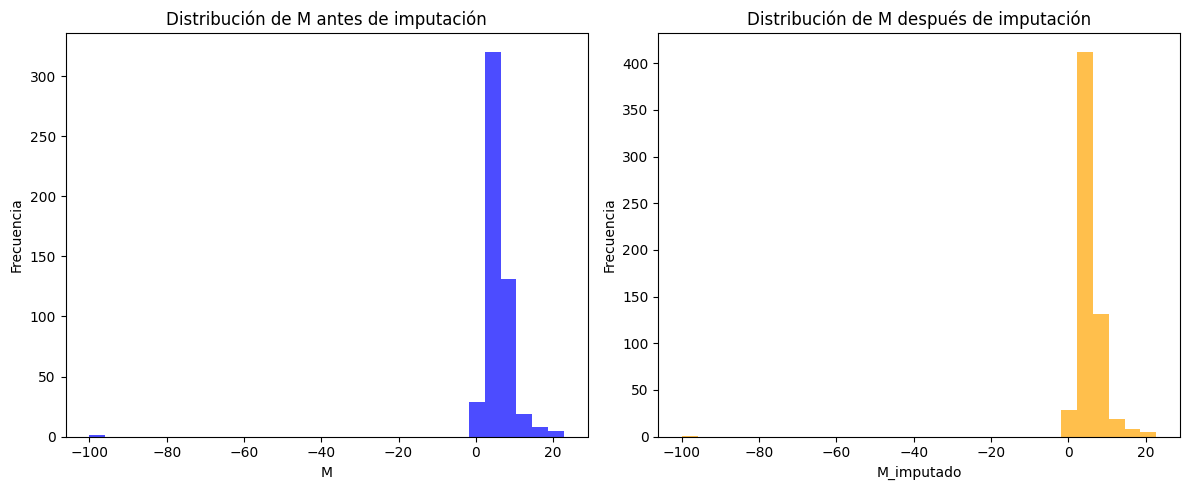

<Figure size 1200x600 with 0 Axes>

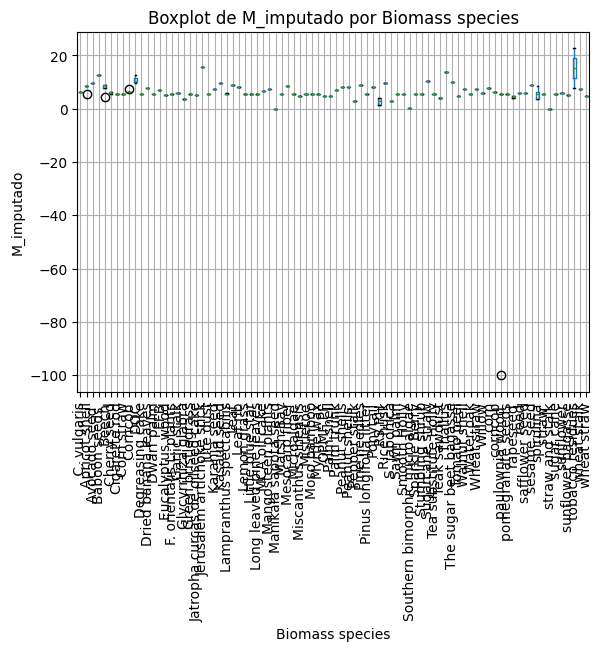

In [13]:
 #Imputación de M
 #23 especies tienen todos sus valores de M nulos, así que necesitamos imputación jerárquica: mediana por especie como primera opción, mediana global como fallback.

mediana_global_M = df['M'].median()
df['M_imputado'] = df.groupby('Biomass species')['M'].transform(
    lambda x: x.fillna(x.median() if x.notna().any() else mediana_global_M)
)
df['M_imputado'] = df['M_imputado'].fillna(mediana_global_M)
print("Mediana global de M:", mediana_global_M)
print("NaN en M_imputado:", df['M_imputado'].isna().sum())

#graficar distribución de M antes y después de imputación
#minimos y maximos del grafico 0 y 100%

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['M'].dropna(), bins=30, color='blue', alpha=0.7)
plt.title('Distribución de M antes de imputación')
plt.xlabel('M')
plt.ylabel('Frecuencia')
plt.subplot(1,2,2)
plt.hist(df['M_imputado'], bins=30, color='orange', alpha=0.7)
plt.title('Distribución de M después de imputación')    
plt.xlabel('M_imputado')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#hacer un boxplot de M_imputado por especie para verificar que la imputación no haya generado valores atípicos
plt.figure(figsize=(12,6))
df.boxplot(column='M_imputado', by='Biomass species', rot=90)
plt.title('Boxplot de M_imputado por Biomass species')
plt.suptitle('')
plt.xlabel('Biomass species')
plt.ylabel('M_imputado')
plt.show()





In [14]:
print(df[df['M'] < 0][['Biomass species', 'M']])


     Biomass species      M
511  paulownia wood  -100.0


In [15]:
#Contar filas con NaN en VM y FC
print("Nulos en ambas a la vez:", df[['VM','FC']].isnull().all(axis=1).sum())


Nulos en ambas a la vez: 68


VM + FC + Ash + M = 100%. Son variables acopladas

In [16]:
# Filas donde VM es nulo pero FC no
print("VM nulo, FC presente:", df[df['VM'].isnull() & df['FC'].notna()][['Biomass species','VM','FC']].head())

# Filas donde FC es nulo pero VM no  
print("FC nulo, VM presente:", df[df['FC'].isnull() & df['VM'].notna()][['Biomass species','VM','FC']].head())

VM nulo, FC presente: Empty DataFrame
Columns: [Biomass species, VM, FC]
Index: []
FC nulo, VM presente: Empty DataFrame
Columns: [Biomass species, VM, FC]
Index: []


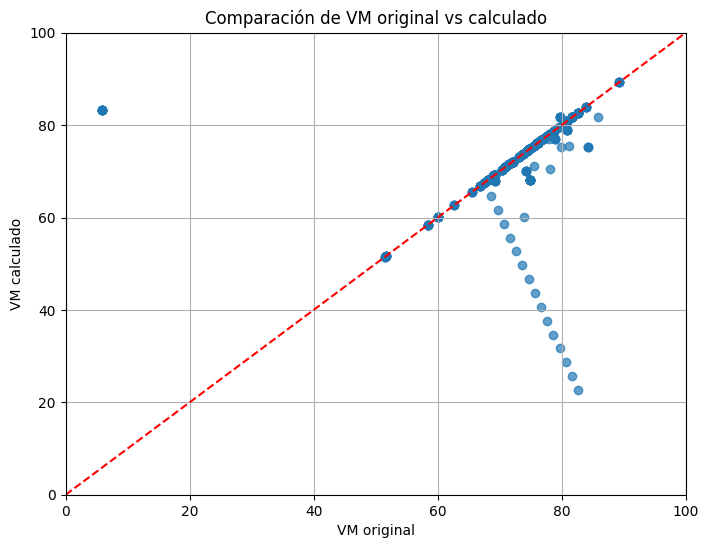

Filas donde VM original y calculado difieren >1%: 70
         Biomass species     VM     FC  Ash      M  VM_calculado
11              Ponytail  78.95  14.04  0.76  8.12         77.08
12              Ponytail  78.95  14.04  0.76  8.12         77.08
13              Ponytail  78.95  14.04  0.76  8.12         77.08
14              Ponytail  78.95  14.04  0.76  8.12         77.08
179  Dried banana leaves  78.20  15.60  6.20  7.80         70.40


In [17]:
VM = 100 - df['FC'] - df['Ash '] - df['M']
df['VM_calculado'] = VM
# Comparar VM calculado con VM original
plt.figure(figsize=(8,6))
plt.scatter(df['VM'], df['VM_calculado'], alpha=0.7)
plt.title('Comparación de VM original vs calculado')
plt.xlabel('VM original')
plt.ylabel('VM calculado')
# Agregar una línea de referencia para la igualdad
plt.plot([0, 100], [0, 100], color='red', linestyle='--')
# Limitar los ejes a 0-100%
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid()
plt.show()
# Contar filas donde la diferencia entre VM original y calculado es mayor a 1%
diferencia = (df['VM'] - df['VM_calculado']).abs()
print("Filas donde VM original y calculado difieren >1%:", (diferencia > 1).sum())
# Mostrar algunas de esas filas para inspección
print(df[diferencia > 1][['Biomass species', 'VM', 'FC', 'Ash ', 'M', 'VM_calculado']].head())


In [18]:
# Solo rellenar donde VM es nulo
df['VM'] = df['VM'].fillna(df['VM_calculado'])
# Verificar que ya no haya NaN en VM
print("NaN en VM después de imputación:", df['VM'].isna().sum())


NaN en VM después de imputación: 68


In [19]:
mediana_global_VM = df['VM'].median()
df['VM'] = df['VM'].fillna(mediana_global_VM)

# Mismo para FC
mediana_global_FC = df['FC'].median()
df['FC'] = df['FC'].fillna(mediana_global_FC)

print("NaN en VM:", df['VM'].isna().sum())
print("NaN en FC:", df['FC'].isna().sum())

NaN en VM: 0
NaN en FC: 0


La ecuación VM = 100 − FC − Ash − M preserva la coherencia fisicoquímica del análisis próximo porque impone el cierre de masa estructural entre fracciones, mientras que la imputación por mediana global introduce un valor estadístico que puede violar esa relación composicional.

VM — Recalculada por cierre de masa

La variable VM presentaba inconsistencias puntuales respecto al análisis próximo.
En biomasa seca, las fracciones VM, FC, Ash y M deben cumplir la relación de cierre:

VM = 100 − FC − Ash − M

Se recalculó VM cuando existían las otras tres fracciones disponibles.
Esta decisión garantiza coherencia fisicoquímica entre componentes del análisis próximo.
Usar la ecuación de cierre es preferible a imputar con la mediana global porque preserva la estructura composicional del sistema y evita introducir valores estadísticos que puedan violar el balance de masa.
Se conservaron los valores originales cuando el cierre era consistente dentro de un margen razonable.
El resultado final mantiene trazabilidad y elimina inconsistencias estructurales sin introducir sesgo artificial.

In [20]:
print(df.isnull().sum().to_string())

Index                0
Biomass species      0
M                   92
Ash                 18
VM                   0
FC                   0
C                    0
H                    0
O                    0
N                    0
PS                  54
FT                   0
HR                  73
FR                 108
Solid phase          0
Liquid phase         0
Gas phase            0
FR_disponible        0
FT_grupo             0
FR_imputado          0
M_imputado           0
VM_calculado       142


In [21]:
print((df['M'] < 0).sum())

1


In [22]:
#eliminar filas con M negativo
filas_antes = len(df)
df = df[df['M'] >= 0]
filas_despues = len(df)
print(f"Filas eliminadas por M negativo: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues}")

Filas eliminadas por M negativo: 93
Filas restantes: 512


In [23]:
# Reemplazar originales con imputados
df['M'] = df['M'].fillna(df['M_imputado'])
df['FR'] = df['FR'].fillna(df['FR_imputado'])

# Eliminar columnas auxiliares
df = df.drop(columns=['M_imputado', 'FR_imputado'])

# Guardar el dataset limpio
CLEAN_PATH = r"C:\Users\santi\Documents\Pyrolisis\Data\pyrolysis_limpio.csv"
df.to_csv(CLEAN_PATH, index=False)

# Verificar que el nuevo dataset no tenga NaN
print(df.isnull().sum().to_string())

# Mostrar las primeras filas del dataset limpio
print(df.head())
# Mostrar la dimensión del dataset limpio
print("Dimensión del dataset limpio:", df.shape)
# Mostrar las columnas del dataset limpio
print("Columnas del dataset limpio:", df.columns.tolist())
# Mostrar estadísticas descriptivas del dataset limpio
print(df.describe().to_string())


Index               0
Biomass species     0
M                   0
Ash                 0
VM                  0
FC                  0
C                   0
H                   0
O                   0
N                   0
PS                 54
FT                  0
HR                 65
FR                  0
Solid phase         0
Liquid phase        0
Gas phase           0
FR_disponible       0
FT_grupo            0
VM_calculado       50
   Index            Biomass species      M  Ash      VM     FC      C     H  \
0      1  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
1      2  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
2      3  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
3      4  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
4      5                       reed   5.89  8.47  72.12  13.52  42.78  5.17   

       O     N   PS   FT    HR     FR  Solid phase  Liquid phase  Gas phase  \
0  47.

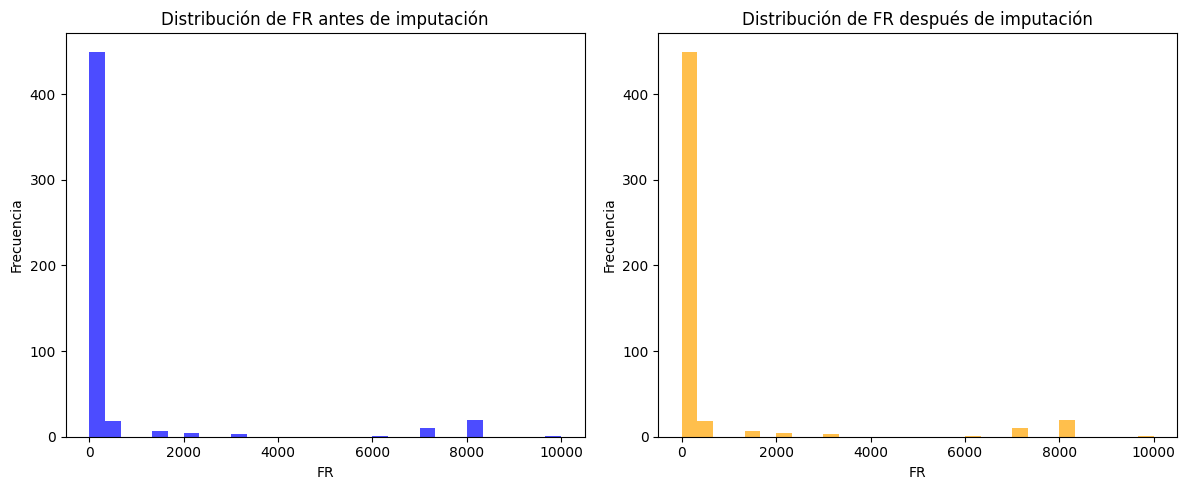

In [27]:
 #mediana por especie con fallback global, igual que hiciste con M. 
df['FR_mediana'] = df.groupby('Biomass species')['FR'].transform(lambda x: x.median())
df['FR'] = df['FR'].fillna(df['FR_mediana'])
df = df.drop(columns=['FR_mediana'])

#graficar distribución de FR antes y después de imputación
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['FR'].dropna(), bins=30, color='blue', alpha=0.7)
plt.title('Distribución de FR antes de imputación')
plt.xlabel('FR')
plt.ylabel('Frecuencia')
plt.subplot(1,2,2)
plt.hist(df['FR'], bins=30, color='orange', alpha=0.7)
plt.title('Distribución de FR después de imputación')
plt.xlabel('FR')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()




In [28]:
print(df[df['FR'] > 1000][['Biomass species', 'FR', 'FT']].sort_values('FR', ascending=False).head(10))

                     Biomass species       FR   FT
695  Jatropha curcas de oilseed cake  10000.0  450
710                     MCA oil cake   8000.0  400
709                     MCA oil cake   8000.0  350
711                     MCA oil cake   8000.0  450
692  Jatropha curcas de oilseed cake   8000.0  450
690  Jatropha curcas de oilseed cake   8000.0  450
713                     MCA oil cake   8000.0  550
714                     MCA oil cake   8000.0  600
686  Jatropha curcas de oilseed cake   8000.0  425
688  Jatropha curcas de oilseed cake   8000.0  475


In [29]:
print(df[df['FR'] > 1000][['Biomass species', 'FR', 'FT', 'Solid phase', 'Liquid phase', 'Gas phase']])

                     Biomass species       FR   FT  Solid phase  Liquid phase  \
23                       Wheat straw   3000.0  400        57.13         25.07   
24                       Wheat straw   3000.0  500        47.70         30.88   
25                       Wheat straw   3000.0  600        47.00         30.70   
74                 Mangosteen plants   1500.0  300        49.50         30.70   
75                 Mangosteen plants   1500.0  400        30.95         48.30   
76                 Mangosteen plants   1500.0  450        29.42         49.01   
77                 Mangosteen plants   1500.0  500        27.15         50.03   
78                 Mangosteen plants   1500.0  550        26.21         50.57   
79                 Mangosteen plants   1500.0  600        25.92         49.70   
80                 Mangosteen plants   1500.0  700        25.10         48.24   
264                       Palm trunk   2000.0  500        40.87         33.60   
265                         

In [ ]:
## FR — valores extremos (>1000 ml/min)
Se identificaron 44 filas con FR entre 1500–10000 ml/min 
concentradas en especies como Jatropha curcas, MCA oil cake, RS/RH.
Los rendimientos de fase son coherentes y suman ~100%.
Se conservan: representan experimentos legítimos a escala diferente,
no errores de carga.

In [30]:
print(df.isnull().sum()[df.isnull().sum() > 0])

PS              54
HR              65
VM_calculado    50
dtype: int64


In [31]:
# 1. Eliminar VM_calculado y FT_grupo
df = df.drop(columns=['VM_calculado', 'FT_grupo'])

# 2. Imputar PS por especie con fallback global
df['PS_mediana'] = df.groupby('Biomass species')['PS'].transform(lambda x: x.median())
df['PS'] = df['PS'].fillna(df['PS_mediana'])
df = df.drop(columns=['PS_mediana'])

# 3. Imputar HR por especie con fallback global
df['HR_mediana'] = df.groupby('Biomass species')['HR'].transform(lambda x: x.median())
df['HR'] = df['HR'].fillna(df['HR_mediana'])
df = df.drop(columns=['HR_mediana'])

# Verificación final
print(df.isnull().sum()[df.isnull().sum() > 0])
# Eliminar filas con M negativo
filas_antes = len(df)
df = df[df['M'] >= 0]
filas_despues = len(df)
print(f"Filas eliminadas por M negativo: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues}")


PS    40
HR    64
dtype: int64
Filas eliminadas por M negativo: 0
Filas restantes: 512


In [33]:
# Imputar PS y HR con mediana global (si quedaran NaN después de imputación por especie)
df['PS'] = df['PS'].fillna(df['PS'].median())
df['HR'] = df['HR'].fillna(df['HR'].median())
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [35]:
CLEAN_PATH = r"C:\Users\santi\Documents\pyrolisis\Data\pyrolysis_clean.csv"
df.to_csv(CLEAN_PATH, index=False)
print("Dataset exportado correctamente")
print("Dimensión final:", df.shape)
print("Columnas:", df.columns.tolist())

Dataset exportado correctamente
Dimensión final: (512, 18)
Columnas: ['Index', 'Biomass species', 'M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'PS', 'FT', 'HR', 'FR', 'Solid phase', 'Liquid phase', 'Gas phase', 'FR_disponible']


In [ ]:
Filas iniciales: 751 → Filas finales: 512 (se perdieron 239).
Se eliminaron 146 filas por cierre de fases: se filtró Solid phase + Liquid phase + Gas phase y se conservaron solo sumas 90–110%; quedaron afuera 107 con balance extremo y 39 con NaN en alguna fase (suma indefinida).
Se eliminó 1 fila con M < 0 (humedad negativa), por ser un valor físicamente inválido no recuperable por imputación.
FR tuvo faltantes no aleatorios: se creó FR_disponible y se imputó FR_imputado por mediana dentro de cuartiles de FT (fallback: mediana global), preservando la señal “medido vs no medido”.
VM se corrigió por cierre del análisis próximo usando VM_calculado = 100 − FC − Ash − M y se rellenó VM solo donde estaba ausente, evitando romper la relación composicional.
PS y HR se imputaron por mediana por Biomass species (fallback: mediana global) y se eliminaron columnas auxiliares (VM_calculado, FT_grupo, imputados) para dejar un dataset final consistente.